dict_keys(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])


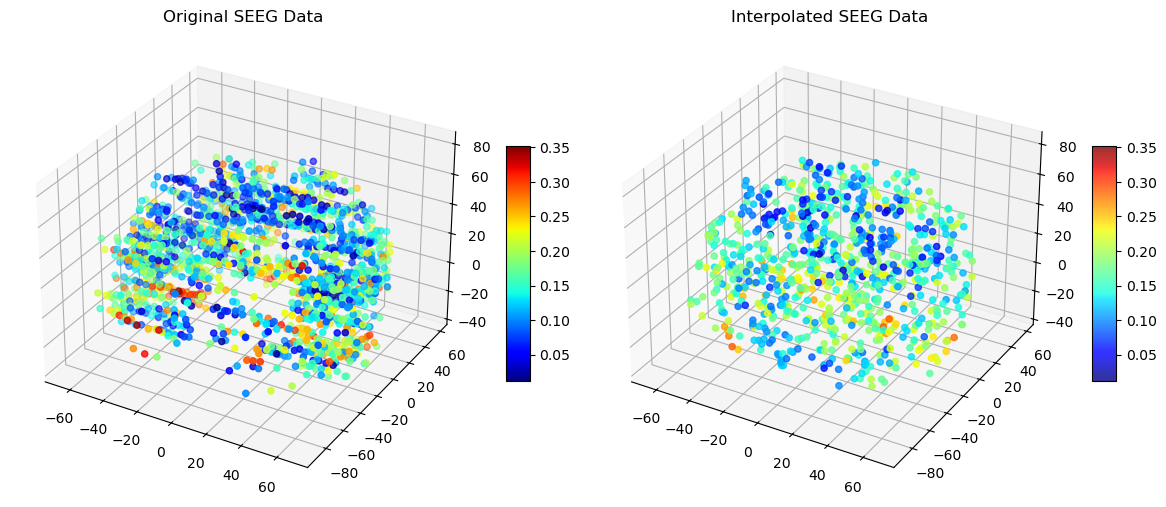

evaluation metrics: {'MSE': 0.0033318781296827263, 'MAE': 0.044798708391890006, 'RMSE': 0.0576919342339012, 'R2': 0.3173399952458709}


In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def load_data():
    coords = np.load('coords.npy')
    band_powers = np.load('band_powers.npy',allow_pickle=True).item()
    print(band_powers.keys())
    return coords, band_powers

def interpolate_smooth(coords, values):
    
  
    grid_x = np.linspace(coords[:, 0].min(), coords[:, 0].max(), len(coords))
    grid_y = np.linspace(coords[:, 1].min(), coords[:, 1].max(), len(coords))
    grid_z = np.linspace(coords[:, 2].min(), coords[:, 2].max(), len(coords))

    
    grid_coords = np.column_stack([
        np.random.choice(grid_x, size=len(coords)),  
        np.random.choice(grid_y, size=len(coords)),  
        np.random.choice(grid_z, size=len(coords))
    ])

    
    interp_values = griddata(coords, values, grid_coords, method='linear')

    return grid_coords, interp_values

def plot_3d_data(coords, values, interp_coords, interp_values):
    fig = plt.figure(figsize=(12, 5))

    vmin = min(values.min(), interp_values.min())  
    vmax = max(values.max(), interp_values.max()) 

    ax1 = fig.add_subplot(121, projection='3d')
    scatter1 = ax1.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=values, cmap='jet', marker='o', vmin=vmin, vmax=vmax)
    ax1.set_title("Original SEEG Data")
    fig.colorbar(scatter1, ax=ax1, shrink=0.5, aspect=10)

    ax2 = fig.add_subplot(122, projection='3d')
    scatter2 = ax2.scatter(interp_coords[:, 0], interp_coords[:, 1], interp_coords[:, 2], c=interp_values, cmap='jet', marker='o', alpha=0.8, vmin=vmin, vmax=vmax)
    ax2.set_title("Interpolated SEEG Data")
    fig.colorbar(scatter2, ax=ax2, shrink=0.5, aspect=10)

    for ax in [ax1, ax2]:
        ax.set_xlim([coords[:, 0].min(), coords[:, 0].max()])
        ax.set_ylim([coords[:, 1].min(), coords[:, 1].max()])
        ax.set_zlim([coords[:, 2].min(), coords[:, 2].max()])

    plt.tight_layout()
    plt.show()

def linear_interpolation(train_coords, train_values, test_coords):

    pred_values = griddata(train_coords, train_values, test_coords, method='linear')
    return pred_values

def calculate_metrics(true_values, pred_values):

    mask = ~np.isnan(pred_values)  # 只计算非 NaN 值
    mse = mean_squared_error(true_values[mask], pred_values[mask])
    mae = mean_absolute_error(true_values[mask], pred_values[mask])
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values[mask], pred_values[mask])
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

# ==========================evaluation ==========================
def cross_validate(coords, values, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    all_metrics = []

    for train_idx, test_idx in kf.split(coords):
        train_coords, test_coords = coords[train_idx], coords[test_idx]
        train_values, test_values = values[train_idx], values[test_idx]

        pred_values = linear_interpolation(train_coords, train_values, test_coords)
        metrics = calculate_metrics(test_values, pred_values)
        all_metrics.append(metrics)

    avg_metrics = {key: np.mean([m[key] for m in all_metrics]) for key in all_metrics[0]}
    return avg_metrics
    
# ========================== main ==========================
def main():
    coords, band_powers = load_data()
    band = 'Delta' 
    band_values = np.array(band_powers[band])

    interp_coords, interp_values = interpolate_smooth(coords, band_values)

    plot_3d_data(coords, band_values, interp_coords, interp_values)

    metrics = cross_validate(coords, band_values, k=5)
    print("evaluation metrics:", metrics)

if __name__ == "__main__":
    main()


dict_keys(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])


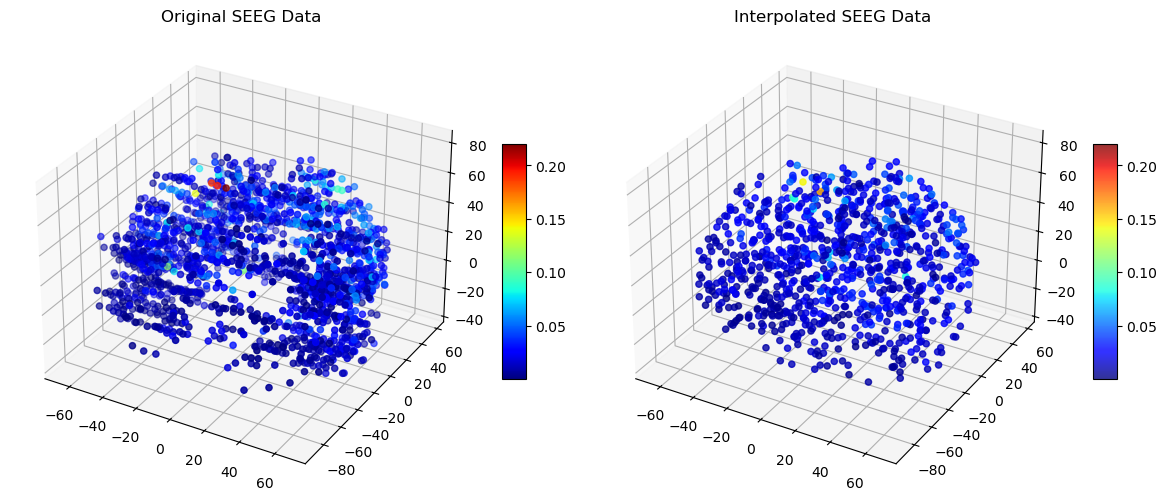

In [8]:
import numpy as np
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def load_data():
    coords = np.load('coords.npy')
    band_powers = np.load('band_powers.npy',allow_pickle=True).item()
    print(band_powers.keys())
    return coords, band_powers

def interpolate_smooth(coords, values):
    
  
    grid_x = np.linspace(coords[:, 0].min(), coords[:, 0].max(), len(coords))
    grid_y = np.linspace(coords[:, 1].min(), coords[:, 1].max(), len(coords))
    grid_z = np.linspace(coords[:, 2].min(), coords[:, 2].max(), len(coords))

    
    grid_coords = np.column_stack([
        np.random.choice(grid_x, size=len(coords)),  
        np.random.choice(grid_y, size=len(coords)),  
        np.random.choice(grid_z, size=len(coords))
    ])

    
    interp_values = griddata(coords, values, grid_coords, method='linear')

    return grid_coords, interp_values

def plot_3d_data(coords, values, interp_coords, interp_values):
    fig = plt.figure(figsize=(12, 5))

    vmin = min(values.min(), interp_values.min())  
    vmax = max(values.max(), interp_values.max()) 

    ax1 = fig.add_subplot(121, projection='3d')
    scatter1 = ax1.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=values, cmap='jet', marker='o', vmin=vmin, vmax=vmax)
    ax1.set_title("Original SEEG Data")
    fig.colorbar(scatter1, ax=ax1, shrink=0.5, aspect=10)

    ax2 = fig.add_subplot(122, projection='3d')
    scatter2 = ax2.scatter(interp_coords[:, 0], interp_coords[:, 1], interp_coords[:, 2], c=interp_values, cmap='jet', marker='o', alpha=0.8, vmin=vmin, vmax=vmax)
    ax2.set_title("Interpolated SEEG Data")
    fig.colorbar(scatter2, ax=ax2, shrink=0.5, aspect=10)

    for ax in [ax1, ax2]:
        ax.set_xlim([coords[:, 0].min(), coords[:, 0].max()])
        ax.set_ylim([coords[:, 1].min(), coords[:, 1].max()])
        ax.set_zlim([coords[:, 2].min(), coords[:, 2].max()])

    plt.tight_layout()
    plt.show()

def linear_interpolation(train_coords, train_values, test_coords):

    pred_values = griddata(train_coords, train_values, test_coords, method='linear')
    return pred_values

    
# ========================== main ==========================
def main():
    coords, band_powers = load_data()
    band = 'Gamma' 
    band_values = np.array(band_powers[band])

    interp_coords, interp_values = interpolate_smooth(coords, band_values)

    plot_3d_data(coords, band_values, interp_coords, interp_values)

if __name__ == "__main__":
    main()


dict_keys(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])


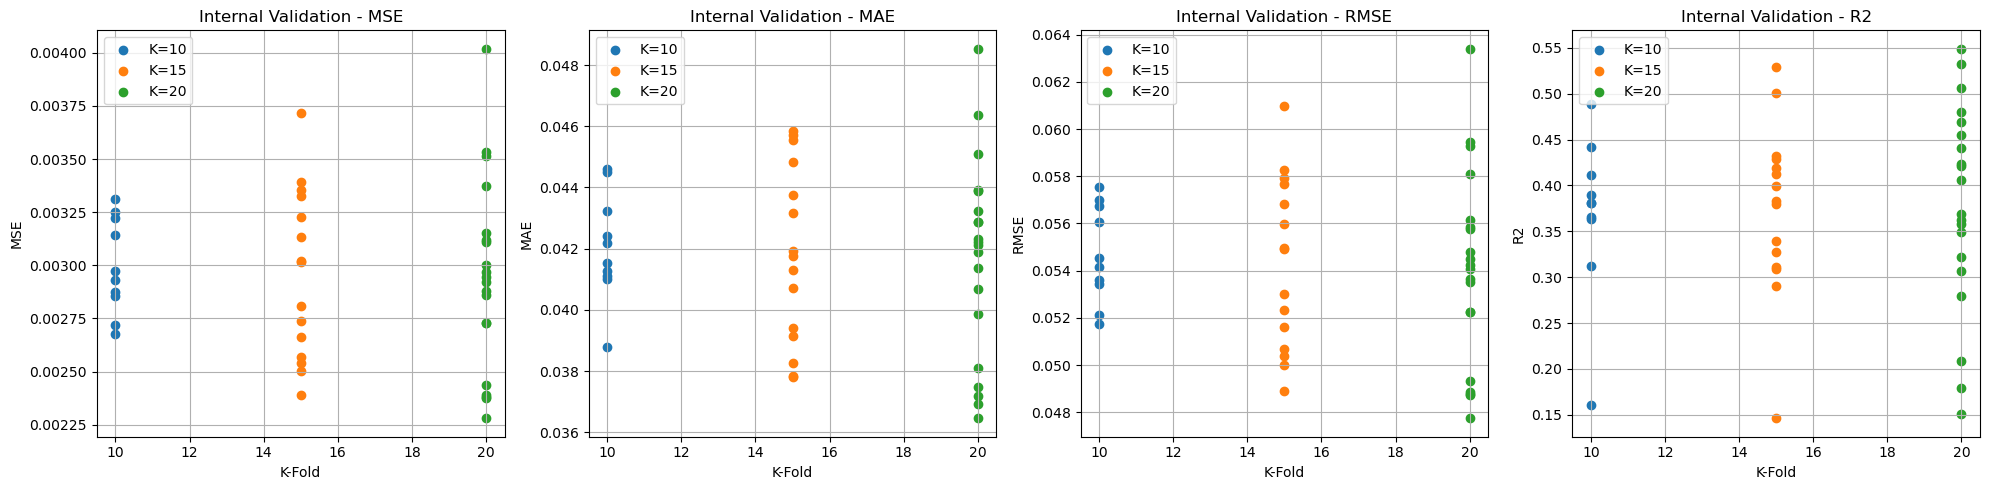

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

def load_data():
    coords = np.load('coords.npy')
    band_powers = np.load('band_powers.npy', allow_pickle=True).item()
    print(band_powers.keys())
    return coords, band_powers

def calculate_metrics(true_values, pred_values):
    mask = ~np.isnan(pred_values)
    if np.sum(mask) == 0:
        return None
    mse = mean_squared_error(true_values[mask], pred_values[mask])
    mae = mean_absolute_error(true_values[mask], pred_values[mask])
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values[mask], pred_values[mask])
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

def cross_validate_internal(coords, values, k_values):
    results = {k: {"MSE": [], "MAE": [], "RMSE": [], "R2": []} for k in k_values}
    scaler = StandardScaler()
    coords = scaler.fit_transform(coords)

    for k in k_values:
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        for train_idx, test_idx in kf.split(coords):
            train_coords, test_coords = coords[train_idx], coords[test_idx]
            train_values, test_values = values[train_idx], values[test_idx]
            pred_values = griddata(train_coords, train_values, test_coords, method='linear')
            pred_values = np.nan_to_num(pred_values, nan=np.mean(train_values))
            
            metrics = calculate_metrics(test_values, pred_values)
            if metrics is None:
                continue

            for metric in results[k]:
                results[k][metric].append(metrics[metric])
    return results

def plot_internal_metrics(internal_metrics, k_values):
    metrics = ["MSE", "MAE", "RMSE", "R2"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for i, metric in enumerate(metrics):
        for k in k_values:
            axes[i].scatter([k] * len(internal_metrics[k][metric]), internal_metrics[k][metric], label=f'K={k}')
        axes[i].set_title(f"Internal Validation - {metric}")
        axes[i].set_ylabel(metric)
        axes[i].set_xlabel("K-Fold")
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

def main():
    coords, band_powers = load_data()
    band = 'Delta'
    if band not in band_powers:
        print(f"Band {band} not found in data.")
        return

    band_values = np.array(band_powers[band])
    k_values = [10, 15, 20]
    internal_metrics = cross_validate_internal(coords, band_values, k_values)
    plot_internal_metrics(internal_metrics, k_values)

if __name__ == "__main__":
    main()
